In [ ]:
import requests
import json
import pandas as pd
import numpy as np
from tqdm import tqdm
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
import os
import pickle
from dotenv import load_dotenv
from pinecone import Pinecone
from langchain_ollama import OllamaEmbeddings, ChatOllama
from langchain_community.retrievers import PineconeHybridSearchRetriever
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from transformers import AutoTokenizer
from huggingface_hub import snapshot_download
from datasets import Dataset
import torch, bitsandbytes as bnb
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig
from trl import SFTTrainer, SFTConfig
import gc
from peft import peft_model

In [12]:
sys_prompt = """You are a retrieval-grounded Quran QA assistant (English). You MUST answer using ONLY the provided retrieved context. The retrieved context may include Qur'an translation text and Tafsir (e.g., Tafsir al-Jalalayn). Treat the context as the ONLY source of truth.

Rules (strict):
1) Do NOT use outside knowledge, memory, or guesses. If the answer is not explicitly supported by the retrieved context, say you do not have enough evidence to answer.
2) Do NOT invent verse numbers, surah names, citations, quotes, or details.
3) Every factual claim about what the Qur'an says or what a story contains MUST be supported by at least one citation from the retrieved context.
4) If the user asks “What did Allah say about X?”, only state what is present in the retrieved context and cite the surah/ayah range. Do NOT paraphrase as a direct quote unless it is clearly a Qur'an translation line in the context. If it is tafsir, label it as tafsir explanation (not a direct Qur'an quote).
5) If retrieved passages are ambiguous or contradictory, explicitly say so and present both views with citations.
6) Keep the tone respectful and neutral. Avoid issuing fatwas or absolute rulings. If the question requires scholarly/legal judgment beyond the context, say so.
7) If the context is insufficient: output "INSUFFICIENT_CONTEXT" and provide 3–7 suggested retrieval keywords/queries that would likely fetch the missing evidence (names, key terms, story elements, concepts). Do NOT answer from guessing.

Output format:
- Answer: (concise, 2–6 sentences max)
- Evidence: bullet list. Each bullet includes: a short support statement + citation in the format (Surah X Ayah A-B).
- Explanation (optional): 2–6 sentences, only if it is supported by context; cite if you add new info.

"""

In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [ ]:
train_df_lora, val_df_lora = train_test_split(train_df, test_size=0.1, random_state=42)

In [ ]:
print(requests.get("https://huggingface.co").status_code)

200


In [ ]:
hf_token = os.getenv("HF_TOKEN")

In [ ]:
snapshot_download(
    repo_id="meta-llama/Llama-3.2-3B-Instruct",
    token=hf_token
)



In [ ]:
BASE_MODEL = "C:\models\Llama-3.2-3B-Instruct"

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, use_fast=True, token=hf_token)


def make_chat_text(row):
    user_content = (
        f"Question:\n{row['question_en']}\n\n"
        f"Context:\n{row['context']}\n\n"
        "Answer using ONLY the context."
    )

    messages = [
        {"role": "system", "content": sys_prompt},
        {"role": "user", "content": user_content},
        {"role": "assistant", "content": str(row["answer_en"])},
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False
    ).strip()

    if tokenizer.eos_token and not text.endswith(tokenizer.eos_token):
        text += tokenizer.eos_token

    return text


In [ ]:
def make_chat_text(row):
    user_content = (
        f"Question:\n{row['question_en']}\n\n"
        f"Context:\n{row['context']}\n\n"
        "Answer using ONLY the context."
    )

    messages = [
        {"role": "system", "content": sys_prompt},
        {"role": "user", "content": user_content},
        {"role": "assistant", "content": str(row["answer_en"])},
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False
    ).strip()

    if tokenizer.eos_token and not text.endswith(tokenizer.eos_token):
        text += tokenizer.eos_token

    return text


In [ ]:
train_texts = [make_chat_text(r) for r in train_df_lora.to_dict("records")]
val_texts   = [make_chat_text(r) for r in val_df_lora.to_dict("records")]

train_ds = Dataset.from_dict({"text": train_texts})
val_ds   = Dataset.from_dict({"text": val_texts})


print("num samples train:", len(train_ds))
print("num samples val:", len(val_ds))

num samples train: 856
num samples val: 96


In [ ]:
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("cuda device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)
print("bnb:", bnb.__version__)

torch: 2.5.1+cu121
cuda available: True
cuda device: NVIDIA GeForce RTX 4070 Laptop GPU
bnb: 0.49.1


In [ ]:
import torch, gc, math
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, default_data_collator
from torch.utils.data import DataLoader
from tqdm import tqdm


bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
)

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, use_fast=True, local_files_only=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_config,
    device_map="auto",
    local_files_only=True,
)
base_model.config.use_cache = False
base_model.config.pad_token_id = tokenizer.pad_token_id


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
from tqdm.auto import tqdm

@torch.no_grad()
def eval_loss(model, dataset, batch_size=1):
    model.eval()
    dl = DataLoader(dataset, batch_size=batch_size, collate_fn=default_data_collator)
    total, n = 0.0, 0
    for batch in tqdm(dl, desc="Eval"):
        batch = {k: v.to(model.device) for k, v in batch.items()}
        out = model(**batch)
        total += float(out.loss.item())
        n += 1
    mean = total / max(n, 1)
    ppl = math.exp(mean) if mean < 50 else float("inf")
    return {"eval_loss": mean, "perplexity": ppl}

# IMPORTANT: val_tok must be prepared and set_format(torch) in this session
metrics_base = eval_loss(base_model, val_tok, batch_size=1)
print("BASE:", metrics_base)


Eval:   0%|          | 0/96 [00:00<?, ?it/s]

BASE: {'eval_loss': 3.29288283487161, 'perplexity': 26.920358848551373}


In [ ]:

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
)

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, use_fast=True, local_files_only=True)

model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_config,
    device_map="auto",
    local_files_only=True,
)

model.config.use_cache = False

# Llama tokenizers often have no pad token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# also make sure model knows it (helps with generation + loss masking)
model.config.pad_token_id = tokenizer.pad_token_id


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
layer_names = {type(m).__name__ for m in model.modules()}
print("Any 4bit layers:", any("4bit" in n.lower() for n in layer_names))
print("Some layer types:", sorted([n for n in layer_names if "4" in n.lower() or "bit" in n.lower()])[:20])


Any 4bit layers: True
Some layer types: ['Linear4bit']


In [ ]:

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Compute capability:", torch.cuda.get_device_capability(0))  # (major, minor)
    print("BF16 supported (PyTorch):", torch.cuda.is_bf16_supported())


CUDA available: True
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
Compute capability: (8, 9)
BF16 supported (PyTorch): True


In [ ]:
import torch, math
from torch.utils.data import DataLoader
from tqdm import tqdm

@torch.no_grad()
def eval_causal_lm_loss(model, dataset, batch_size=1):
    model.eval()
    dl = DataLoader(dataset, batch_size=batch_size)

    total_loss, total_batches = 0.0, 0

    for batch in tqdm(dl, desc="Evaluating"):
        # convert any lists to tensors + move to device
        fixed = {}
        for k, v in batch.items():
            if isinstance(v, list):
                v = torch.tensor(v)
            fixed[k] = v.to(model.device)

        out = model(**fixed)
        loss = out.loss

        total_loss += float(loss.item())
        total_batches += 1

    mean_loss = total_loss / max(total_batches, 1)
    ppl = math.exp(mean_loss) if mean_loss < 50 else float("inf")
    return {"eval_loss": mean_loss, "perplexity": ppl}


In [ ]:
cols = ["input_ids", "attention_mask", "labels"]
val_tok.set_format(type="torch", columns=cols)


metrics_before = eval_causal_lm_loss(base_model, val_tok, batch_size=1)
print("BEFORE:", metrics_before)

metrics_after = eval_causal_lm_loss(trainer.model, val_tok, batch_size=1)
print("AFTER:", metrics_after)


In [ ]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
)

model = get_peft_model(model, lora_config)


In [ ]:
model.print_trainable_parameters()

trainable params: 12,156,928 || all params: 3,224,906,752 || trainable%: 0.3770


In [ ]:
MAX_LEN = 2048

def tokenize_batch(batch):
    enc = tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LEN,
        padding="max_length",
    )

    labels = []
    for ids, mask in zip(enc["input_ids"], enc["attention_mask"]):
        # ignore padding tokens in loss
        labels.append([tok if m == 1 else -100 for tok, m in zip(ids, mask)])

    enc["labels"] = labels
    return enc


train_tok = train_ds.map(tokenize_batch, batched=True, remove_columns=train_ds.column_names)
val_tok   = val_ds.map(tokenize_batch, batched=True, remove_columns=val_ds.column_names)


Map:   0%|          | 0/856 [00:00<?, ? examples/s]

Map:   0%|          | 0/96 [00:00<?, ? examples/s]

In [ ]:
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling

OUT_DIR = "./qlora_llama32_quran"

args = TrainingArguments(
    output_dir=OUT_DIR,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=16,
    learning_rate=2e-4,
    num_train_epochs=1,
    logging_steps=10,
    save_steps=200,
    report_to="none",
    bf16=True,
    remove_unused_columns=False,
)

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    data_collator=data_collator,
)

trainer.train()
trainer.save_model(OUT_DIR)
print("Saved LoRA adapter to:", OUT_DIR)


C:\Users\LOQ\Documents\GitHub\PythonProject3\.venv\Lib\site-packages\torch\_dynamo\eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
10,2.553400
20,1.373700
30,1.080000
40,1.007200
50,1.051000


Saved LoRA adapter to: ./qlora_llama32_quran


In [ ]:

# 1) Delete common big objects if they exist
for name in list(globals().keys()):
    if name in ["model", "base_model", "trainer", "ft", "retriever", "pipe", "llm"]:
        try:
            del globals()[name]
        except:
            pass

# 2) Collect Python garbage
gc.collect()

# 3) Clear CUDA cache + IPC (helps in notebooks)
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

# 4) Show memory now
if torch.cuda.is_available():
    print(torch.cuda.memory_allocated()/1024**3, "GB allocated")
    print(torch.cuda.memory_reserved()/1024**3, "GB reserved")


4.368410110473633 GB allocated
6.119140625 GB reserved


In [ ]:
metrics_after = trainer.evaluate()
print("AFTER eval_loss:", metrics_after.get("eval_loss"))

In [ ]:
ADAPTER_DIR = r"./qlora_llama32_quran"

In [ ]:


bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
)

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, use_fast=True, local_files_only=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_config,
    device_map="auto",
    local_files_only=True,
)
base_model.config.use_cache = False
base_model.config.pad_token_id = tokenizer.pad_token_id


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
model = PeftModel.from_pretrained(base_model, ADAPTER_DIR)
model.eval()


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(128256, 3072)
        (layers): ModuleList(
          (0-27): 28 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=3072, out_features=3072, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=3072, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=3072, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora.L

In [ ]:
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling

args = TrainingArguments(
    output_dir="./tmp",
    per_device_eval_batch_size=1,
    report_to="none",
    remove_unused_columns=False,
    fp16=True,
)

collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

trainer = Trainer(
    model=model,
    args=args,
    eval_dataset=val_tok,          # you must rebuild val_tok in this session too
    data_collator=collator,
)


In [ ]:
trainer.evaluate()

{'eval_loss': 0.9202656745910645,
 'eval_model_preparation_time': 0.0092,
 'eval_runtime': 77.2526,
 'eval_samples_per_second': 1.243,
 'eval_steps_per_second': 1.243}

/tmp/ipython-input-2442444218.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


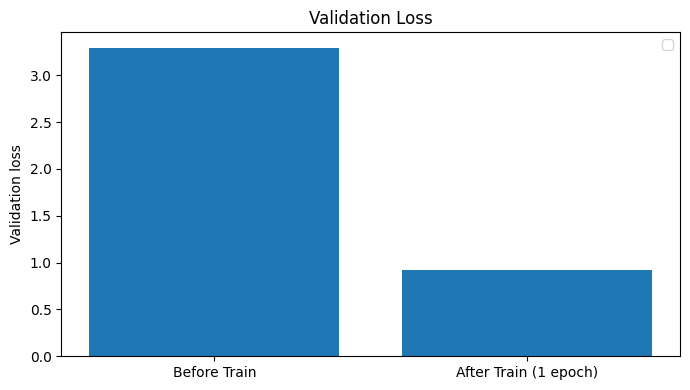

In [10]:
import numpy as np
import matplotlib.pyplot as plt

val = ["Before Train", "After Train (1 epoch)"]


m1 = [3.29288283487161, 0.9202656745910645]

x = np.arange(len(val))
width = 0.1

plt.figure(figsize=(7,4))
plt.bar(x, m1)

plt.xticks(x, val)
plt.ylabel("Validation loss")
plt.title("Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()